In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# **Job Title Counts**

In [2]:
df.pivot_table(index='job_title_short', aggfunc='size')

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

# **Median Salary Count by Country**

In [9]:
df.pivot_table(index='job_country', values='salary_year_avg', columns='job_title_short', aggfunc='median').sample(10)

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Jamaica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100000.0
Austria,NaN,NaN,80850.00,147500.0,71249.75,89100.0,89100.0,147500.0,80850.0,NaN
Luxembourg,NaN,NaN,57600.00,89100.0,157500.00,89100.0,NaN,NaN,NaN,56700.0
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Morocco,NaN,NaN,84337.50,140870.5,117000.00,NaN,NaN,69300.0,NaN,NaN
Denmark,NaN,NaN,89100.00,122136.5,109500.00,135650.0,NaN,147500.0,NaN,NaN
Guam,90000.0,NaN,92500.00,NaN,NaN,195000.0,103750.0,NaN,137500.0,127500.0
Guatemala,NaN,NaN,NaN,80000.0,NaN,NaN,NaN,NaN,57500.0,NaN
Switzerland,56700.0,NaN,57500.00,147500.0,107575.00,89100.0,NaN,165000.0,89100.0,89100.0


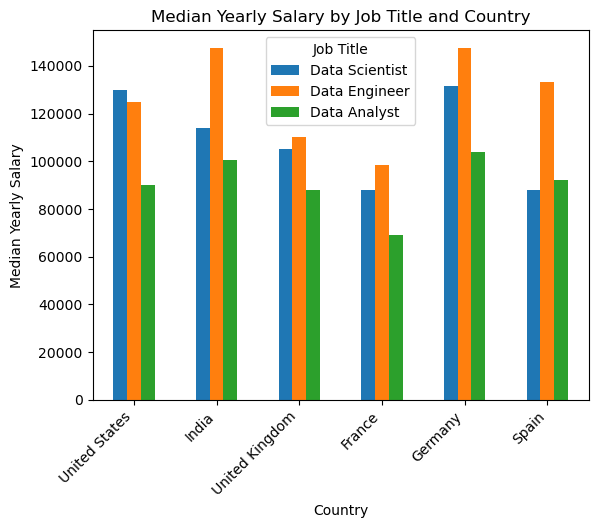

In [24]:
top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df.pivot_table(
    index='job_country',
    values='salary_year_avg',
    columns='job_title_short',
    aggfunc='median'
)

df_job_country_salary = df_job_country_salary.loc[top_countries]

job_title = ['Data Scientist', 'Data Engineer', 'Data Analyst']

df_job_country_salary = df_job_country_salary[job_title]

df_job_country_salary.plot(kind='bar')
plt.title('Median Yearly Salary by Job Title and Country')
plt.xlabel('Country')
plt.ylabel('Median Yearly Salary')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Title')
plt.show()